In [4]:
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
sys.path.append('../')

import skimage
import dinomn.mnds as mnds

# Performance

In [11]:
df = pd.read_csv('/scr/yren/dinomn_figures/figure3/figure3_data.csv')
df.head()

,Precision,Recall,Model,Dataset
0,0.74,0.62,DinoMN,BBBC039
1,0.89,0.92,DinoMN,Pilot_Screen
2,0.83,0.88,DinoMN,HeLa_RPE1
3,0.77,0.75,DinoMN,MNFinder Data
4,0.62,0.68,MNFinder,BBBC039


In [12]:
for group_keys, group_df in df.groupby(['Model']):
    print(f'Group: {group_keys}')
    print(group_df)
    print('------')

Group: ('Cellpose',)
    Precision  Recall     Model        Dataset
8        0.70    0.29  Cellpose        BBBC039
9        0.82    0.15  Cellpose   Pilot_Screen
10       0.83    0.16  Cellpose      HeLa_RPE1
11       0.73    0.25  Cellpose  MNFinder Data
------
Group: ('DinoMN',)
   Precision  Recall   Model        Dataset
0       0.74    0.62  DinoMN        BBBC039
1       0.89    0.92  DinoMN   Pilot_Screen
2       0.83    0.88  DinoMN      HeLa_RPE1
3       0.77    0.75  DinoMN  MNFinder Data
------
Group: ('MNFinder',)
   Precision  Recall     Model        Dataset
4       0.62    0.68  MNFinder        BBBC039
5       0.69    0.83  MNFinder   Pilot_Screen
6       0.67    0.81  MNFinder      HeLa_RPE1
7       0.85    0.86  MNFinder  MNFinder Data
------
Group: ('microSAM',)
    Precision  Recall     Model        Dataset
12       0.45    0.10  microSAM        BBBC039
13       0.05    0.00  microSAM   Pilot_Screen
14       0.39    0.02  microSAM      HeLa_RPE1
15       0.56    0.09  m

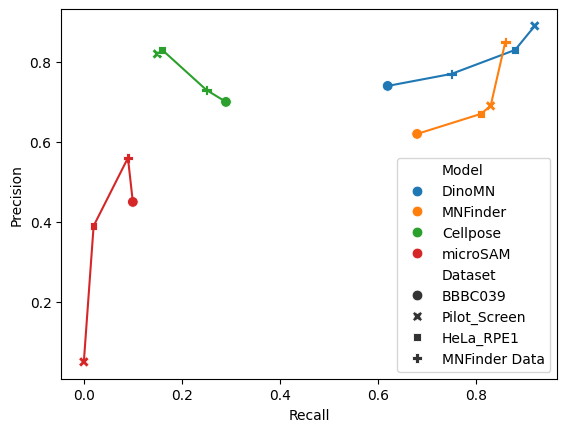

In [13]:
x = sb.scatterplot(
    data=df,
    x='Recall',
    y='Precision',
    hue='Model',
    style='Dataset',
    s=60
)

# Get color palette used by seaborn
palette = dict(zip(df['Model'].unique(), sb.color_palette()))

# Loop over each Model, ignore Dataset
for model, group_data in df.groupby('Model'):
    group_data = group_data.sort_values('Recall')  # sort so lines look clean
    plt.plot(
        group_data['Recall'],
        group_data['Precision'],
        color=palette[model],
        marker=None,
        linestyle='-'
    )
plt.show()

# Object Size

In [14]:
def compare_two_labels(label_model, label_gt, return_IoU_matrix, debug=False):
    
    # get number of detected nuclei
    nb_nuclei_gt = np.max(label_gt)
    nb_nuclei_model = np.max(label_model)
    
    # catch the case of an empty picture in model and gt
    if nb_nuclei_gt == 0 and nb_nuclei_model == 0:
        if(return_IoU_matrix):
            return [0, 0, 1, np.empty(0)]     
        else:
            return [0, 0, 1]
    
    # catch the case of empty picture in model
    if nb_nuclei_model == 0:
        if(return_IoU_matrix):
            return [0, nb_nuclei_gt, 0, np.empty(0)]     
        else:
            return [0, nb_nuclei_gt, 0]
    
    # catch the case of empty picture in gt
    if nb_nuclei_gt == 0:
        if(return_IoU_matrix):
            return [nb_nuclei_model, 0, 0, np.empty(0)]     
        else:
            return [nb_nuclei_model, 0, 0]
    
    # build IoU matrix
    IoUs = np.full((nb_nuclei_gt, nb_nuclei_model), -1.0, dtype = np.float32)

    # calculate IoU for each nucleus index_gt in GT and nucleus index_pred in prediction    
    # TODO improve runtime of this algorithm
    for index_gt in range(1,nb_nuclei_gt+1):

        nucleus_gt = label_gt == index_gt
        number_gt = np.sum(nucleus_gt)

        for index_model in range(1,nb_nuclei_model+1):
            
            if debug:
                print(index_gt, "/", index_model)
            
            nucleus_model = label_model == index_model 
            number_model = np.sum(nucleus_model)
            
            same_and_1 = np.sum((nucleus_gt == nucleus_model) * nucleus_gt)
            
            IoUs[index_gt-1,index_model-1] = same_and_1 / (number_gt + number_model - same_and_1)
    
    # get matches and errors
    detection_map = (IoUs > 0.5)
    nb_matches = np.sum(detection_map)

    detection_rate = IoUs * detection_map
    
    nb_overdetection = nb_nuclei_model - nb_matches
    nb_underdetection = nb_nuclei_gt - nb_matches
    
    mean_IoU = np.mean(np.sum(detection_rate, axis = 1))
    
    if(return_IoU_matrix):
        result = [nb_overdetection, nb_underdetection, mean_IoU, IoUs]
    else:
        result = [nb_overdetection, nb_underdetection, mean_IoU]
    return result

def measures_at(threshold, IOU):
    matches = IOU > threshold
    
    true_positives = np.sum(matches, axis=1) == 1   # Correct objects
    false_positives = np.sum(matches, axis=0) == 0  # Extra objects
    false_negatives = np.sum(matches, axis=1) == 0  # Missed objects
    
    assert np.all(np.less_equal(true_positives, 1))
    assert np.all(np.less_equal(false_positives, 1))
    assert np.all(np.less_equal(false_negatives, 1))
    
    TP, FP, FN = np.sum(true_positives), np.sum(false_positives), np.sum(false_negatives)
    
    f1 = 2*TP / (2*TP + FP + FN + 1e-9)

    prec = TP / (TP + FP)

    rec = TP / (TP + FN)

    return f1, prec, rec, TP, FP, FN

In [15]:
# Hyperparameters
DIRECTORY = '/scr/yren/micronuclei-detection/dinomn/all_data_micronuclei_no_rescale/validation'
OUTPUT_DIR = '/model_output/output/'
SCALE_FACTOR = 1.0
THRESHOLD = 0.5

In [10]:
filelist = os.listdir(DIRECTORY + OUTPUT_DIR)
files = [file for file in filelist if file.endswith('_probabilities.npy')]
print(len(files))

47


In [16]:
for file in files:
    imid = file.split('.')[0]
    prob = np.load(DIRECTORY + OUTPUT_DIR + file)
    mn_pred = prob > THRESHOLD
    mn_gt = mnds.read_image(DIRECTORY, imid, 'phenotype_outlines.png', scale=SCALE_FACTOR)
    
    pi = skimage.morphology.label(mn_pred)
    gti = skimage.morphology.label(mn_gt)
    nb_overdetection, nb_underdetection, mean_IoU, IoUs = compare_two_labels(pi, gti, True)
    
    matches = IoUs > 0.1
    ratio = []
    for i in range(0, matches.shape[0]):
        if (True in matches[i,:]):
            idx = np.where(matches[i,:]==True)[0][0]
            label_gt = i + 1
            label_pred = idx + 1
            
            area_gt = np.sum(gti == label_gt)
            area_pred = np.sum(pi == label_pred)
            ratio.append(area_gt/area_pred)
        else:
            ratio.append(0)
    
    print(imid, matches.shape, len(np.unique(pi)))
    mat = np.column_stack((matches, ratio))
    IoU_filename = f'/scr/yren/dinomn_figures/figure3/IoUs/{imid}._IoUs.npy'
    np.save(IoU_filename, mat)

2022-05-26_RPE1-2198 (113, 84) 85
2022-10-14_U2OS-1 (63, 40) 41
2023-05-31_misc-4 (4, 7) 8
20X_c0-DAPI_A1_Tile-50 (163, 162) 163
C1-20X_c0_B3_Tile-24 (170, 163) 164
C1-20X_c0_phalloidin_C3_Tile-15 (75, 86) 87
C2-20X_c0-DAPI-GFP_A2_Tile-5 (83, 91) 92
C2-20X_c0-DAPI-GFP_B3_Tile-16 (100, 99) 100
IXMtest_B04_s4_w1F6AEFA0F-AF87-4B3B-A334-698647CFE043 (9, 9) 10
IXMtest_B12_s2_w19F7E0279-D087-4B5E-9899-61971C29CB78 (10, 7) 8
IXMtest_B19_s7_w1E43B84DB-39E2-4BFB-8CB4-554B32098C75 (7, 4) 5
IXMtest_B24_s9_w18C4FE0DD-12CA-4711-9722-3E3105D1E691 (5, 6) 7
IXMtest_C18_s1_w11C16FC59-2E29-496A-803A-89581FDF538A (12, 13) 14
IXMtest_D02_s8_w1AC6783DF-ED35-4818-8091-E6D02AF4BFBD (16, 20) 21
IXMtest_D07_s4_w16CF58D03-0B05-41FE-AE73-7298887DEBB1 (8, 10) 11
IXMtest_D19_s6_w1EB1F11AE-4FB6-481F-94D9-40246870F0CB (11, 8) 9
IXMtest_E06_s3_w1701573EB-CE9A-4D76-8668-0416996E1DCD (9, 5) 6
IXMtest_E12_s9_w1A811DEC0-ADD9-411A-B5D5-A654C70F253D (5, 4) 5
IXMtest_F08_s1_w144C3056F-C4DD-4D39-A40F-4F4576A6DBD8 (8, 7) 8
IX

In [17]:
path = '/scr/yren/dinomn_figures/figure3/IoUs/'
filelist = os.listdir(path)
IoU_files = [file for file in filelist if file.endswith('._IoUs.npy')]
print(len(IoU_files))

47


## Plot

In [19]:
path = '/scr/yren/dinomn_figures/figure3/IoUs/'
DIRECTORY = '/scr/yren/micronuclei-detection/dinomn/all_data_micronuclei_no_rescale/validation'
OUTPUT_DIR = '/model_output/output/'
SCALE_FACTOR = 1.0
THRESHOLD = 0.5

import pandas as pd

df = pd.DataFrame(columns = ['original_area', 'predicted_area', 'status'])

for i in range(len(IoU_files)):
    IoU_path = path + IoU_files[i]
    matches = np.load(IoU_path)
    matches = matches[:,:-1] # remove last column which is ratio
    
    imid = IoU_files[i].split('.')[0]
    mn_pred = np.load(f'{DIRECTORY}{OUTPUT_DIR}{imid}._probabilities.npy') > THRESHOLD
    
    mn_gt = mnds.read_image(DIRECTORY, imid, 'phenotype_outlines.png', scale=SCALE_FACTOR)
    mn_gt = mn_gt > 0
    
    pi = skimage.morphology.label(mn_pred)
    gti = skimage.morphology.label(mn_gt)
    
    original_area = []
    predicted_area = []
    status = [] # True/Flase
    
    for j in range(0, matches.shape[0]): # not detected should be 0 for predicted area
        if (True in matches[j,:]):
            idx = np.where(matches[j,:]==True)[0][0]
            label_gt = j + 1
            label_pred = idx + 1
            
            area_gt = np.sum(gti == label_gt)
            area_pred = np.sum(pi == label_pred)
            
            original_area.append(area_gt)
            predicted_area.append(area_pred)
            status.append('Detected') # detected
            
        else: # ground truth is not predicted by the model
            label_gt = j + 1
            area_gt = np.sum(gti == label_gt)
            area_pred = 0
            
            original_area.append(area_gt)
            predicted_area.append(area_pred)
            status.append('Missed') # not detected
            
    df_single_image = pd.DataFrame({'original_area':original_area, 'predicted_area':predicted_area, 'status':status})
    df = pd.concat([df, df_single_image], ignore_index=True)

In [20]:
df.head()

,original_area,predicted_area,status
0,2,0,Missed
1,127,0,Missed
2,28,36,Detected
3,3,0,Missed
4,8,12,Detected


In [21]:
df_detected = df[df['status'] == 'Detected'].copy()
df_detected['original_area'] = pd.to_numeric(df_detected['original_area'])
df_detected['predicted_area'] = pd.to_numeric(df_detected['predicted_area'])

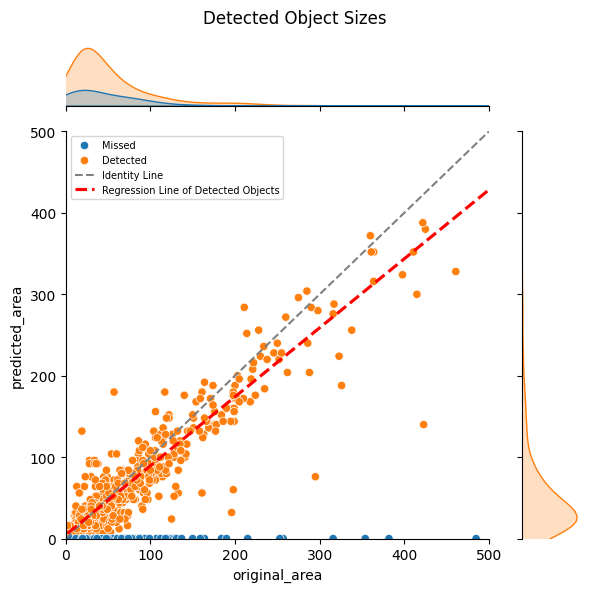

In [27]:
IoU_files_figure = sb.jointplot(data=df, x='original_area', y='predicted_area', hue='status')
IoU_files_figure.figure.suptitle('Detected Object Sizes')
# plt.axhline(y=0, color='red')
plt.ylim([0,500])
plt.xlim([0,500])
plt.xlabel('Original Size')
plt.ylabel('Predicted Size')
ax = IoU_files_figure.ax_joint
# Add identity line
lims = [0, 500]
ax.plot(lims, lims, '--', color='gray', label='Identity Line')
ax.legend()

sb.regplot(
    data=df_detected,
    x='original_area',
    y='predicted_area',
    scatter=False,       # don't add more scatter points
    ax=ax,
    ci=None,
    color='red',
    line_kws={'linestyle':'--'},
    label='Regression Line of Detected Objects'
)

plt.legend(fontsize=7)
plt.tight_layout()
plt.show()